In [1]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Mid-level
        self.mid_level = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(192, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, out_channels, kernel_size=2, stride=2, output_padding=0)  # Adjusted output_padding
        )

    def forward(self, x):
        # Encoder
        x1 = self.encoder(x)

        # Mid-level
        x2 = self.mid_level(x1)

        # Decoder
        x3 = self.decoder(x2)

        return x3

# Example usage:
in_channels = 1  # Assuming grayscale images
out_channels = 1  # Assuming binary segmentation output

# Adjust the model instantiation
model = UNet(in_channels, out_channels)
# model.load_state_dict(torch.load('unet_model.pth'))

In [2]:
from torchsummary import summary

summary(model.cuda(), (1,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]             640
              ReLU-2         [-1, 64, 128, 128]               0
            Conv2d-3         [-1, 64, 128, 128]          36,928
              ReLU-4         [-1, 64, 128, 128]               0
         MaxPool2d-5           [-1, 64, 64, 64]               0
            Conv2d-6          [-1, 128, 64, 64]          73,856
              ReLU-7          [-1, 128, 64, 64]               0
            Conv2d-8          [-1, 128, 64, 64]         147,584
              ReLU-9          [-1, 128, 64, 64]               0
           Conv2d-10          [-1, 192, 64, 64]         221,376
             ReLU-11          [-1, 192, 64, 64]               0
           Conv2d-12          [-1, 128, 64, 64]         221,312
             ReLU-13          [-1, 128, 64, 64]               0
           Conv2d-14           [-1, 64,

In [3]:
import os
import numpy as np
from PIL import Image
from skimage.morphology import dilation, area_closing
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class ERDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)

    def __len__(self):
        return sum(len(os.listdir(os.path.join(self.root_dir, cls, 'images'))) for cls in self.classes)

    def __getitem__(self, idx):
        current_class_idx = 0
        while idx >= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images'))):
            idx -= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images')))
            current_class_idx += 1

        current_class = self.classes[current_class_idx]
        img_folder = os.path.join(self.root_dir, current_class, 'images')
        mask_folder = os.path.join(self.root_dir, current_class, 'adaptive_mask')

        img_name = os.listdir(img_folder)[idx]
        img_path = os.path.join(img_folder, img_name)
        mask_name = os.path.splitext(img_name)[0] + '_mask.png'  # Assuming mask files have the same name as images with '_mask' appended
        mask_path = os.path.join(mask_folder, mask_name)

        image = Image.open(img_path)#.convert("RGB")
        mask = Image.open(mask_path)#.convert("L")  # Convert to grayscale mask

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /local-scratch/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


In [6]:
# # Tips to incorporate the topological loss into your own framework
# # You have to pretrain your model first and then fine-tune with topoloss, see the rationale part of our paper
# # train(pretrain_epoch, topo_epoch):
# #    for i in range(0, topo_epoch):
# #       if (i<= pretrain_epoch):
# #         loss = nn.CrossEntropyLoss();
# #       else:
# #         loss = nn.CrossEntropyLoss() + lambda * getTopoLoss(lh, gt);

# import time
# import numpy
# import gudhi as gd
# from pylab import *
# import torch


# def compute_dgm_force(lh_dgm, gt_dgm, pers_thresh=0.03, pers_thresh_perfect=0.99, do_return_perfect=False):
#     """
#     Compute the persistent diagram of the image

#     Args:
#         lh_dgm: likelihood persistent diagram.
#         gt_dgm: ground truth persistent diagram.
#         pers_thresh: Persistent threshold, which also called dynamic value, which measure the difference.
#         between the local maximum critical point value with its neighouboring minimum critical point value.
#         The value smaller than the persistent threshold should be filtered. Default: 0.03
#         pers_thresh_perfect: The distance difference between two critical points that can be considered as
#         correct match. Default: 0.99
#         do_return_perfect: Return the persistent point or not from the matching. Default: False

#     Returns:
#         force_list: The matching between the likelihood and ground truth persistent diagram
#         idx_holes_to_fix: The index of persistent points that requires to fix in the following training process
#         idx_holes_to_remove: The index of persistent points that require to remove for the following training
#         process

#     """
#     lh_pers = abs(lh_dgm[:, 1] - lh_dgm[:, 0])
#     if (gt_dgm.shape[0] == 0):
#         gt_pers = None;
#         gt_n_holes = 0;
#     else:
#         gt_pers = gt_dgm[:, 1] - gt_dgm[:, 0]
#         gt_n_holes = gt_pers.size  # number of holes in gt

#     if (gt_pers is None or gt_n_holes == 0):
#         idx_holes_to_fix = list();
#         idx_holes_to_remove = list(set(range(lh_pers.size)))
#         idx_holes_perfect = list();
#     else:
#         # check to ensure that all gt dots have persistence 1
#         tmp = gt_pers > pers_thresh_perfect

#         # get "perfect holes" - holes which do not need to be fixed, i.e., find top
#         # lh_n_holes_perfect indices
#         # check to ensure that at least one dot has persistence 1; it is the hole
#         # formed by the padded boundary
#         # if no hole is ~1 (ie >.999) then just take all holes with max values
#         tmp = lh_pers > pers_thresh_perfect  # old: assert tmp.sum() >= 1
#         lh_pers_sorted_indices = np.argsort(lh_pers)[::-1]
#         if np.sum(tmp) >= 1:
#             lh_n_holes_perfect = tmp.sum()
#             idx_holes_perfect = lh_pers_sorted_indices[:lh_n_holes_perfect];
#         else:
#             idx_holes_perfect = list();

#         # find top gt_n_holes indices
#         idx_holes_to_fix_or_perfect = lh_pers_sorted_indices[:gt_n_holes];

#         # the difference is holes to be fixed to perfect
#         idx_holes_to_fix = list(
#             set(idx_holes_to_fix_or_perfect) - set(idx_holes_perfect))

#         # remaining holes are all to be removed
#         idx_holes_to_remove = lh_pers_sorted_indices[gt_n_holes:];

#     # only select the ones whose persistence is large enough
#     # set a threshold to remove meaningless persistence dots
#     pers_thd = pers_thresh
#     idx_valid = np.where(lh_pers > pers_thd)[0]
#     idx_holes_to_remove = list(
#         set(idx_holes_to_remove).intersection(set(idx_valid)))

#     force_list = np.zeros(lh_dgm.shape)
    
#     # push each hole-to-fix to (0,1)
#     force_list[idx_holes_to_fix, 0] = 0 - lh_dgm[idx_holes_to_fix, 0]
#     force_list[idx_holes_to_fix, 1] = 1 - lh_dgm[idx_holes_to_fix, 1]

#     # push each hole-to-remove to (0,1)
#     force_list[idx_holes_to_remove, 0] = lh_pers[idx_holes_to_remove] / \
#                                          math.sqrt(2.0)
#     force_list[idx_holes_to_remove, 1] = -lh_pers[idx_holes_to_remove] / \
#                                          math.sqrt(2.0)

#     if (do_return_perfect):
#         return force_list, idx_holes_to_fix, idx_holes_to_remove, idx_holes_perfect

#     return force_list, idx_holes_to_fix, idx_holes_to_remove

# def getCriticalPoints(likelihood):
#     """
#     Compute the critical points of the image (Value range from 0 -> 1)

#     Args:
#         likelihood: Likelihood image from the output of the neural networks

#     Returns:
#         pd_lh:  persistence diagram.
#         bcp_lh: Birth critical points.
#         dcp_lh: Death critical points.
#         Bool:   Skip the process if number of matching pairs is zero.

#     """
#     lh = 1 - likelihood
#     lh_vector = np.asarray(lh).flatten()

#     lh_cubic = gd.CubicalComplex(
#         dimensions=[lh.shape[0], lh.shape[1]],
#         top_dimensional_cells=lh_vector
#     )

#     Diag_lh = lh_cubic.persistence(homology_coeff_field=2, min_persistence=0)
#     pairs_lh = lh_cubic.cofaces_of_persistence_pairs()

#     # If the paris is 0, return False to skip
#     if (len(pairs_lh[0])==0): return 0, 0, 0, False

#     # return persistence diagram, birth/death critical points
#     pd_lh = numpy.array([[lh_vector[pairs_lh[0][0][i][0]], lh_vector[pairs_lh[0][0][i][1]]] for i in range(len(pairs_lh[0][0]))])
#     bcp_lh = numpy.array([[pairs_lh[0][0][i][0]//lh.shape[1], pairs_lh[0][0][i][0]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])
#     dcp_lh = numpy.array([[pairs_lh[0][0][i][1]//lh.shape[1], pairs_lh[0][0][i][1]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])

#     return pd_lh, bcp_lh, dcp_lh, True

# def getTopoLoss(likelihood_tensor, gt_tensor, topo_size=100):
#     """
#     Calculate the topology loss of the predicted image and ground truth image 
#     Warning: To make sure the topology loss is able to back-propagation, likelihood 
#     tensor requires to clone before detach from GPUs. In the end, you can hook the
#     likelihood tensor to GPUs device.

#     Args:
#         likelihood_tensor:   The likelihood pytorch tensor.
#         gt_tensor        :   The groundtruth of pytorch tensor.
#         topo_size        :   The size of the patch is used. Default: 100

#     Returns:
#         loss_topo        :   The topology loss value (tensor)

#     """

#     likelihood = torch.sigmoid(likelihood_tensor).clone()
#     gt = gt_tensor.clone()

#     likelihood = torch.squeeze(likelihood).cpu().detach().numpy()
#     gt = torch.squeeze(gt).cpu().detach().numpy()

#     topo_cp_weight_map = np.zeros(likelihood.shape)
#     topo_cp_ref_map = np.zeros(likelihood.shape)

#     for y in range(0, likelihood.shape[0], topo_size):
#         for x in range(0, likelihood.shape[1], topo_size):

#             lh_patch = likelihood[y:min(y + topo_size, likelihood.shape[0]),
#                          x:min(x + topo_size, likelihood.shape[1])]
#             gt_patch = gt[y:min(y + topo_size, gt.shape[0]),
#                          x:min(x + topo_size, gt.shape[1])]

#             if(np.min(lh_patch) == 1 or np.max(lh_patch) == 0): continue
#             if(np.min(gt_patch) == 1 or np.max(gt_patch) == 0): continue

#             # Get the critical points of predictions and ground truth
#             pd_lh, bcp_lh, dcp_lh, pairs_lh_pa = getCriticalPoints(lh_patch)
#             pd_gt, bcp_gt, dcp_gt, pairs_lh_gt = getCriticalPoints(gt_patch)

#             # If the pairs not exist, continue for the next loop
#             if not(pairs_lh_pa): continue
#             if not(pairs_lh_gt): continue

#             force_list, idx_holes_to_fix, idx_holes_to_remove = compute_dgm_force(pd_lh, pd_gt, pers_thresh=0.03)

#             if (len(idx_holes_to_fix) > 0 or len(idx_holes_to_remove) > 0):
#                 for hole_indx in idx_holes_to_fix:
#                     if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[0] and int(
#                             bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) < likelihood.shape[1]):
#                         topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
#                             bcp_lh[hole_indx][1])] = 1  # push birth to 0 i.e. min birth prob or likelihood
#                         topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 0
#                     if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
#                         0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
#                             likelihood.shape[1]):
#                         topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
#                             dcp_lh[hole_indx][1])] = 1  # push death to 1 i.e. max death prob or likelihood
#                         topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 1
#                 for hole_indx in idx_holes_to_remove:
#                     if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
#                         0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
#                             likelihood.shape[1]):
#                         topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
#                             bcp_lh[hole_indx][1])] = 1  # push birth to death  # push to diagonal
#                         if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
#                             0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
#                                 likelihood.shape[1]):
#                             topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = \
#                                 lh_patch[int(dcp_lh[hole_indx][0]), int(dcp_lh[hole_indx][1])]
#                         else:
#                             topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 1
#                     if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
#                         0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
#                             likelihood.shape[1]):
#                         topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
#                             dcp_lh[hole_indx][1])] = 1  # push death to birth # push to diagonal
#                         if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
#                             0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
#                                 likelihood.shape[1]):
#                             topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = \
#                                 lh_patch[int(bcp_lh[hole_indx][0]), int(bcp_lh[hole_indx][1])]
#                         else:
#                             topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 0

#     topo_cp_weight_map = torch.tensor(topo_cp_weight_map, dtype=torch.float).cuda()
#     topo_cp_ref_map = torch.tensor(topo_cp_ref_map, dtype=torch.float).cuda()

#     # Measuring the MSE loss between predicted critical points and reference critical points
#     loss_topo = (((likelihood_tensor * topo_cp_weight_map) - topo_cp_ref_map) ** 2).sum()
#     return loss_topo


# # if __name__ == "__main__":
# #     gt = 1 - imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/masks/rtn6_er_mean_mask.png')
# #     lh = 1 - imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/pred_mask.png')

# #     loss_topo = getTopoLoss(lh, gt)
# #     print(loss_topo)
# #     print('time %.3f'%(time.time()-t0));

In [11]:
# from topologylayer.nn import AlphaLayer, LevelSetLayer2D, BarcodePolyFeature, PartialSumBarcodeLengths, SumBarcodeLengths, TopKBarcodeLengths
# import torch, numpy as np, matplotlib.pyplot as plt
# from torch.nn.functional import sigmoid, relu


# ## Symmetric Topology Loss based on Gabrielsson's work
# ## DS Sep 2023

# class TopologyLoss(torch.nn.Module):
#     def __init__(self, k=49, size=(32, 32)):
#         super(TopologyLoss, self).__init__()
#         self.pd_feat = LevelSetLayer2D(size=size,  sublevel=False)
#         self.f1 = PartialSumBarcodeLengths(dim=0, skip=k)
#         self.f2 = TopKBarcodeLengths(dim=0, k=k)
#         self.f3 = TopKBarcodeLengths(dim=1, k=k)
#         self.f4 = SumBarcodeLengths(dim=0)
#         self.size = size
#         self.k = k

#     def forward(self, x):
#         total_loss = 0

#         for j in range(x.shape[0]):
#             xx = x[j].squeeze() # this loss is for grayscale images only!
#             pd = self.pd_feat(xx)
#             pd_ = self.pd_feat(1-xx)
#             loss = self.f1(pd) + torch.mean((1 - self.f2(pd))**2) + torch.mean((1 - self.f3(pd_))**2) + self.f4(pd_)  + torch.mean(sigmoid(xx)**2)
#             total_loss += loss
        
#         return total_loss/(j + 1) # average over batch



# class TopologyLossBaseline(torch.nn.Module):
#     def __init__(self, k=49, size=(32, 32)):
#         super(TopologyLossBaseline, self).__init__()
#         self.pd_feat = LevelSetLayer2D(size=size,  sublevel=False)
#         self.f1 = PartialSumBarcodeLengths(dim=0, skip=k)
#         self.f2 = TopKBarcodeLengths(dim=0, k=k)
#         self.f3 = TopKBarcodeLengths(dim=1, k=k)
#         self.f4 = SumBarcodeLengths(dim=0)
#         self.size = size

#     def forward(self, x):
#         total_loss = 0

#         for j in range(x.shape[0]):
#             xx = x[j].squeeze() # this loss is for grayscale images only!
#             pd = self.pd_feat(xx)
#             # pd_ = self.pd_feat(1-xx)
#             loss = self.f1(pd) + torch.mean((1 - self.f2(pd))**2)  + torch.mean(sigmoid(xx)**0.5)
#             total_loss += loss
        
#         return total_loss/(j + 1) # average over batch

In [12]:
# Tips to incorporate the topological loss into your own framework
# You have to pretrain your model first and then fine-tune with topoloss, see the rationale part of our paper
# train(pretrain_epoch, topo_epoch):
#    for i in range(0, topo_epoch):
#       if (i<= pretrain_epoch):
#         loss = nn.CrossEntropyLoss();
#       else:
#         loss = nn.CrossEntropyLoss() + lambda * getTopoLoss(lh, gt);


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import torch.nn.functional as F

from monai.losses.dice import DiceLoss
from monai.losses import DiceCELoss, GeneralizedDiceLoss
# from model import NerdyNet
# from dataloader import ERDataset

from torch.nn.modules.loss import _WeightedLoss

import numpy as np

np.random.seed(34)
torch.manual_seed(34)

class SmoothBCEwLogits(_WeightedLoss):
    def __init__(self, weight=None, reduction='mean', smoothing=0.0):
        super().__init__(weight=weight, reduction=reduction)
        self.smoothing = smoothing
        self.weight = weight
        self.reduction = reduction

    @staticmethod
    def _smooth(targets:torch.Tensor, n_labels:int, smoothing=0.0):
        assert 0 <= smoothing < 1
        with torch.no_grad():
            targets = targets * (1.0 - smoothing) + 0.5 * smoothing
        return targets

    def forward(self, inputs, targets, weights=None):
        # print(inputs.shape, targets.shape)
        targets = SmoothBCEwLogits._smooth(targets, inputs.size(-1),
            self.smoothing)
        loss = F.binary_cross_entropy_with_logits(inputs, targets, weights)

        if  self.reduction == 'sum':
            loss = loss.sum()
        elif  self.reduction == 'mean':
            loss = loss.mean()

        return loss

# criterion = nn.BCEWithLogitsLoss()
# criterion = DiceLoss()
# criterion = GeneralizedDiceLoss()

bce = nn.BCEWithLogitsLoss()
# gdice = GeneralizedDiceLoss()
dice = DiceCELoss()


label_smoothing = 1e-2

# not really useful
criterion = SmoothBCEwLogits(smoothing=label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=0.001)

#TODO: Add data augmentation


# Define your transformation
transform = transforms.Compose([
#     transforms.Resize((128, 128)),
    transforms.ToTensor(),
    #transforms.GaussianBlur(3),
    #transforms.RandomHorizontalFlip(p=0.6)
])

# Define your dataset

root_dir = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/'

dataset = ERDataset(root_dir, transform=transform)


# Assuming an 80-20 train-test split
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 100
topo_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
#         outputs = (torch.sigmoid(outputs) > 0.5).float()
#         loss = criterion(outputs, masks)
#         loss = bce(outputs, masks) + dice(outputs, masks)
        loss = bce(outputs, masks) + F.kl_div(torch.log(F.softmax(outputs, dim=1)), torch.log(F.softmax(masks, dim=1)), reduction='batchmean')

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")
    
    if epoch % 9 == 0:
        # Testing loop
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for inputs, masks in test_loader:
                inputs, masks = inputs.to(device), masks.to(device)

                # Forward pass
                outputs = model(inputs)
#                 loss = criterion(outputs, masks)
#                 loss = bce(outputs, masks) + dice(outputs, masks)
                loss = bce(outputs, masks) + F.kl_div(torch.log(F.softmax(outputs, dim=1)), torch.log(F.softmax(masks, dim=1)), reduction='batchmean')
                test_loss += loss.item()

        # Calculate and print the average test loss
        average_test_loss = test_loss / len(test_loader)
        print(f"Average Test Loss: {average_test_loss}")
        

# for epoch in range(topo_epochs):
#     model.train()
#     for inputs, masks in train_loader:
#         inputs, masks = inputs.to(device), masks.to(device)

#         # Forward pass
#         outputs = model(inputs)
        
# #         outputs = (torch.sigmoid(outputs) > 0.5).float()
#         loss = criterion(outputs, masks) + 0.0001 * getTopoLoss(outputs, masks)

#         # Backward pass and optimization
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()


# Save the trained model
# torch.save(model.state_dict(), 'unet_oct26_adaptive_mask_SmoothBCE.pth')

Epoch [1/100], Training Loss: 0.1353873759508133
Average Test Loss: 0.2040712684392929
Epoch [2/100], Training Loss: 0.10064341872930527
Epoch [3/100], Training Loss: 0.1103740930557251
Epoch [4/100], Training Loss: 0.051496610045433044
Epoch [5/100], Training Loss: 0.06497174501419067
Epoch [6/100], Training Loss: 0.10027720779180527
Epoch [7/100], Training Loss: 0.048829950392246246
Epoch [8/100], Training Loss: 0.04034228250384331
Epoch [9/100], Training Loss: 0.049115002155303955
Epoch [10/100], Training Loss: 0.028467347845435143
Average Test Loss: 0.16257625818252563
Epoch [11/100], Training Loss: 0.04479347914457321
Epoch [12/100], Training Loss: 0.034301865845918655
Epoch [13/100], Training Loss: 0.021442994475364685
Epoch [14/100], Training Loss: 0.0150886420160532
Epoch [15/100], Training Loss: 0.01739174872636795
Epoch [16/100], Training Loss: 0.018596705049276352
Epoch [17/100], Training Loss: 0.011464474722743034
Epoch [18/100], Training Loss: 0.009716547094285488
Epoch [1

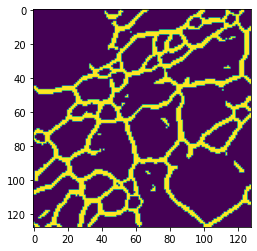

In [28]:
from skimage import restoration
import copy
from skimage.filters import threshold_otsu

imgpath = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/images/rtn22_er_mean.png'

image = Image.open(imgpath)
transform = transforms.Compose([
    transforms.ToTensor(),
])

image = transform(image)
image = image.unsqueeze(0)  # Add batch dimension

# Forward pass through the model
model.eval()
with torch.no_grad():
    output = model(image.cuda())

# Convert the output to probabilities by applying the sigmoid activation
output_probs = torch.sigmoid(output)

# Convert tensors to numpy arrays for visualization
image_np = image.squeeze().numpy()
output_probs_np = output_probs.cpu().squeeze().numpy()

norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

rb = restoration.rolling_ball(norm)
subt = norm - rb

thr = threshold_otsu(subt)

subt2 = copy.deepcopy(subt)

subt2[subt < thr] = 0.
subt2[subt >= thr] = 255.

import matplotlib.pyplot as plt
plt.imshow(subt2)


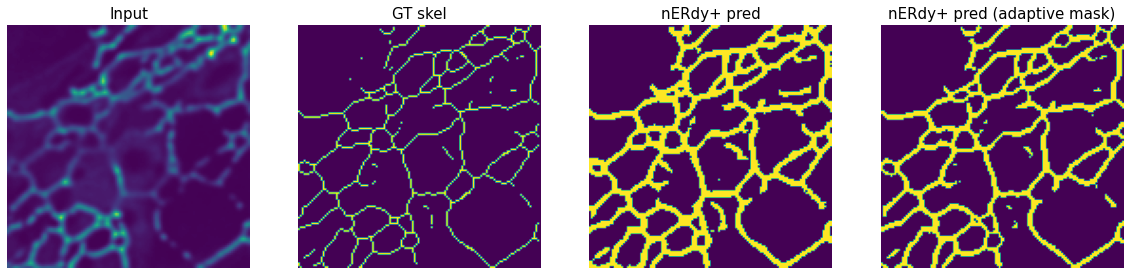

In [29]:
import imageio
ip = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/images/rtn22_er_mean.png')
gt = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/skel/rtn22_proc_skel.png')
nerdy_op = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/predictions/rtn22_er_mean_pred.png')
adaptive_op = subt2

plt.figure(figsize=(20, 10))

plt.subplot(141)
plt.imshow(ip)
plt.title('Input', fontsize=15)
plt.axis('off')

plt.subplot(142)
plt.imshow(gt)
plt.title('GT skel', fontsize=15)
plt.axis('off')

plt.subplot(143)
plt.imshow(nerdy_op)
plt.title('nERdy+ pred', fontsize=15)
plt.axis('off')

plt.subplot(144)
plt.imshow(adaptive_op)
plt.title('nERdy+ pred (adaptive mask)', fontsize=15)
plt.axis('off')

plt.show()

In [10]:
from skimage import restoration
from skimage.filters import threshold_otsu
import copy
import imageio

groups = ['climp', 'control', 'rtn']

for group in groups:
    for i in range(1, 17):
        try:
            imgpath = f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/images/sted_{group}{i}_er_mean.png'

            image = Image.open(imgpath)
            transform = transforms.Compose([
                transforms.ToTensor(),
            ])

            image = transform(image)
            image = image.unsqueeze(0)  # Add batch dimension

            # Forward pass through the model
            model.eval()
            with torch.no_grad():
                output = model(image.cuda())

            # Convert the output to probabilities by applying the sigmoid activation
            output_probs = torch.sigmoid(output)

            # Convert tensors to numpy arrays for visualization
            image_np = image.squeeze().numpy()
            output_probs_np = output_probs.cpu().squeeze().numpy()

            norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

            rb = restoration.rolling_ball(norm)
            subt = norm - rb

            thr = threshold_otsu(subt)

            subt2 = copy.deepcopy(subt)

            subt2[subt < thr] = 0.
            subt2[subt >= thr] = 255.

            imageio.imsave(f'/localhome/asa420/MIAL/data/sted-data/vess_enh_unet/{group}/nerdynet_v2/sted_{group}{i}_er_mean_pred.png', subt2)

        except:
            pass

2023-10-17 18:14:40,665 - Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
2023-10-17 18:14:40,862 - Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
2023-10-17 18:14:41,061 - Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
2023-10-17 18:14:41,268 - Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
2023-10-17 18:14:41,478 - Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
2023-10-17 18:14:41,677 - Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.
2023-10-17 18:14:41,884 - Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert 

In [ ]:
# Tips to incorporate the topological loss into your own framework
# You have to pretrain your model first and then fine-tune with topoloss, see the rationale part of our paper
# train(pretrain_epoch, topo_epoch):
#    for i in range(0, topo_epoch):
#       if (i<= pretrain_epoch):
#         loss = nn.CrossEntropyLoss();
#       else:
#         loss = nn.CrossEntropyLoss() + lambda * getTopoLoss(lh, gt);

import time
import numpy
import gudhi as gd
from pylab import *
import torch

t0=time.time();

def compute_dgm_force(lh_dgm, gt_dgm, pers_thresh=0, pers_thresh_perfect=0.99, do_return_perfect=False):

    lh_pers = abs(lh_dgm[:, 1] - lh_dgm[:, 0])
    if (gt_dgm.shape[0] == 0):
        gt_pers = None;
        gt_n_holes = 0;
    else:
        gt_pers = gt_dgm[:, 1] - gt_dgm[:, 0]
        gt_n_holes = gt_pers.size  # number of holes in gt
        # gt_n_holes = (gt_pers > 0.03).sum()  # number of holes in gt # ignore flat ones

    if (gt_pers is None or gt_n_holes == 0):
        idx_holes_to_fix = list();
        idx_holes_to_remove = list(set(range(lh_pers.size)))
        idx_holes_perfect = list();
    else:
        # more lh dots than gt dots

        # print (lh_pers.shape)
        # print(lh_pers.size)
        # print (gt_pers.shape)
        # assert lh_pers.size > gt_pers.size
        assert lh_pers.size >= gt_n_holes
        if (lh_pers.size < gt_n_holes):
            gt_n_holes = lh_pers.size

        # check to ensure that all gt dots have persistence 1
        tmp = gt_pers > pers_thresh_perfect

        # assert tmp.sum() == gt_pers.size

        # get "perfect holes" - holes which do not need to be fixed, i.e., find top
        # lh_n_holes_perfect indices
        # check to ensure that at least one dot has persistence 1; it is the hole
        # formed by the padded boundary
        # if no hole is ~1 (ie >.999) then just take all holes with max values
        tmp = lh_pers > pers_thresh_perfect  # old: assert tmp.sum() >= 1
        # print('pers_thresh_perfect', pers_thresh_perfect)
        # print('lh_pers > pers_thresh_perfect', (lh_pers > pers_thresh_perfect).sum())
        # print (type(tmp))
        lh_pers_sorted_indices = np.argsort(lh_pers)[::-1]
        if np.sum(tmp) >= 1:
            # if tmp.sum >= 1:
            # n_holes_to_fix = gt_n_holes - lh_n_holes_perfect
            lh_n_holes_perfect = tmp.sum()
            # idx_holes_perfect = np.argpartition(lh_pers, -lh_n_holes_perfect)[
            #                    -lh_n_holes_perfect:]
            idx_holes_perfect = lh_pers_sorted_indices[:lh_n_holes_perfect];
        else:
            # idx_holes_perfect = np.where(lh_pers == lh_pers.max())[0]
            idx_holes_perfect = list();

        # find top gt_n_holes indices
        # idx_holes_to_fix_or_perfect = np.argpartition(lh_pers, -gt_n_holes)[
        #                              -gt_n_holes:]
        idx_holes_to_fix_or_perfect = lh_pers_sorted_indices[:gt_n_holes];

        # the difference is holes to be fixed to perfect
        idx_holes_to_fix = list(
            set(idx_holes_to_fix_or_perfect) - set(idx_holes_perfect))

        # remaining holes are all to be removed
        # idx_holes_to_remove = list(
        #    set(range(lh_pers.size)) - set(idx_holes_to_fix_or_perfect))
        idx_holes_to_remove = lh_pers_sorted_indices[gt_n_holes:];

    # only select the ones whose persistence is large enough
    # set a threshold to remove meaningless persistence dots
    # TODO values below this are small dents so dont fix them; tune this value?
    pers_thd = pers_thresh
    idx_valid = np.where(lh_pers > pers_thd)[0]
    idx_holes_to_remove = list(
        set(idx_holes_to_remove).intersection(set(idx_valid)))

    force_list = np.zeros(lh_dgm.shape)
    # push each hole-to-fix to (0,1)
    force_list[idx_holes_to_fix, 0] = 0 - lh_dgm[idx_holes_to_fix, 0]
    force_list[idx_holes_to_fix, 1] = 1 - lh_dgm[idx_holes_to_fix, 1]

    # push each hole-to-remove to (0,1)
    force_list[idx_holes_to_remove, 0] = lh_pers[idx_holes_to_remove] / \
                                         math.sqrt(2.0)
    force_list[idx_holes_to_remove, 1] = -lh_pers[idx_holes_to_remove] / \
                                         math.sqrt(2.0)

    if (do_return_perfect):
        return force_list, idx_holes_to_fix, idx_holes_to_remove, idx_holes_perfect

    return force_list, idx_holes_to_fix, idx_holes_to_remove

def getCriticalPoints(likelihood):

    lh = 1 - likelihood
    lh_vector = np.asarray(lh).flatten()

    lh_cubic = gd.CubicalComplex(
        dimensions=[lh.shape[0], lh.shape[1]],
        top_dimensional_cells=lh_vector
    )

    Diag_lh = lh_cubic.persistence(homology_coeff_field=2, min_persistence=0)
    pairs_lh = lh_cubic.cofaces_of_persistence_pairs()

    # if(torch.min(lh_patch) == 1 or torch.max(lh_patch) == 0): continue
    # if(torch.min(gt_patch) == 1 or torch.max(gt_patch) == 0): continue
    
    # return persistence diagram, birth/death critical points
    pd_lh = numpy.array([[lh_vector[pairs_lh[0][0][i][0]], lh_vector[pairs_lh[0][0][i][1]]] for i in range(len(pairs_lh[0][0]))])
    bcp_lh = numpy.array([[pairs_lh[0][0][i][0]//lh.shape[1], pairs_lh[0][0][i][0]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])
    dcp_lh = numpy.array([[pairs_lh[0][0][i][1]//lh.shape[1], pairs_lh[0][0][i][1]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])

    return pd_lh, bcp_lh, dcp_lh

def getTopoLoss(likelihood, gt):
    # topo_size = likelihood.shape[0]
    topo_size = 100
    topo_cp_weight_map = np.zeros(likelihood.shape)
    topo_cp_ref_map = np.zeros(likelihood.shape)

    for y in range(0, likelihood.shape[0], topo_size):
        for x in range(0, likelihood.shape[1], topo_size):

            lh_patch = likelihood[y:min(y + topo_size, likelihood.shape[0]),
                         x:min(x + topo_size, likelihood.shape[1])]
            gt_patch = gt[y:min(y + topo_size, gt.shape[0]),
                         x:min(x + topo_size, gt.shape[1])]

            # if(torch.min(lh_patch) == 1 or torch.max(lh_patch) == 0): continue
            # if(torch.min(gt_patch) == 1 or torch.max(gt_patch) == 0): continue
            
            pd_gt, bcp_gt, dcp_gt = getCriticalPoints(gt_patch)
            pd_lh, bcp_lh, dcp_lh = getCriticalPoints(lh_patch)


            force_list, idx_holes_to_fix, idx_holes_to_remove = compute_dgm_force(pd_lh, pd_gt, pers_thresh=0)

            if (len(idx_holes_to_fix) > 0 or len(idx_holes_to_remove) > 0):

                for hole_indx in idx_holes_to_fix:

                    if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[0] and int(
                            bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) < likelihood.shape[1]):
                        topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
                            bcp_lh[hole_indx][1])] = 1  # push birth to 0 i.e. min birth prob or likelihood
                        topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 0
                    # if(y+int(dcp_lh[hole_indx][0]) < et_dmap.shape[2] and x+int(dcp_lh[hole_indx][1]) < et_dmap.shape[3]):
                    if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
                            dcp_lh[hole_indx][1])] = 1  # push death to 1 i.e. max death prob or likelihood
                        topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 1
                for hole_indx in idx_holes_to_remove:

                    if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
                            bcp_lh[hole_indx][1])] = 1  # push birth to death  # push to diagonal
                        # if(int(dcp_lh[hole_indx][0]) < likelihood.shape[0] and int(dcp_lh[hole_indx][1]) < likelihood.shape[1]):
                        if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                            0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                                likelihood.shape[1]):
                            topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = \
                                lh_patch[int(dcp_lh[hole_indx][0]), int(dcp_lh[hole_indx][1])]
                        else:
                            topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 1
                            # if(y+int(dcp_lh[hole_indx][0]) < et_dmap.shape[2] and x+int(dcp_lh[hole_indx][1]) < et_dmap.shape[3]):
                    if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
                            dcp_lh[hole_indx][1])] = 1  # push death to birth # push to diagonal
                        # if(int(bcp_lh[hole_indx][0]) < likelihood.shape[0] and int(bcp_lh[hole_indx][1]) < likelihood.shape[1]):
                        if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
                            0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
                                likelihood.shape[1]):
                            topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = \
                                lh_patch[int(bcp_lh[hole_indx][0]), int(bcp_lh[hole_indx][1])]
                        else:
                            topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 0

    # topo_cp_weight_map = torch.tensor(topo_cp_weight_map, dtype=torch.float).to(device)
    # topo_cp_ref_map = torch.tensor(topo_cp_ref_map, dtype=torch.float).to(device)
    loss_topo = (((likelihood * topo_cp_weight_map) - topo_cp_ref_map) ** 2).sum()

    return loss_topo


if __name__ == "__main__":
    gt = 1 - imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/masks/rtn6_er_mean_mask.png')
    lh = 1 - imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/pred_mask.png')

    loss_topo = getTopoLoss(lh, gt)
    print(loss_topo)
    print('time %.3f'%(time.time()-t0));